# 油耗預測模型分析 — 主要影響因子、殘差、反事實

對應命題要求與評分：

| 分析 | 命題出處 | 評分維度 |
|---|---|---|
| 主要影響因子（TreeSHAP） | 「油耗預測建模方式與模型說明，**包含主要影響因子**」 | 油耗預測 25% |
| 模型學到的養護效果曲線 | 「從歷史資料中學到效能如何隨時間變化、又如何在養護後恢復」 | 油耗預測 |
| 殘差分析 | 模型可信度（無系統性盲區） | 技術可行性 15% |
| **反事實清潔效益** | 「同一套模型也應能反事實推論**在現況下執行 UWC 或 PP 的節能效益**」 | 商務決策 20% |

> 注意：本 notebook 使用當前參數訓練（Optuna 調參完成後重跑本檔即自動採用最佳參數）。


In [1]:
# %% 環境與模型訓練
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from pathlib import Path

plt.rcParams.update({
    "font.family": ["Microsoft JhengHei", "sans-serif"], "axes.unicode_minus": False,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.titlesize": 13, "axes.titleweight": "bold",
})
CAT = {"blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "violet": "#4a3aa7",
       "red": "#e34948", "orange": "#eb6834"}
GRAY, INK = "#8a8a86", "#383835"
FIG = Path("../docs/figures")
def save(name): plt.savefig(FIG / f"{name}.png"); print("saved:", name)

from app.pipeline.predict102 import (build_dataset, _trainable, _fit, _feature_cols,
                                     masked_window_validation)
df, targets = build_dataset()
train = _trainable(df)
model, cols = _fit(train)
print(f"訓練列 {len(train)} | 特徵 {len(cols)}（含 {sum(c.startswith('ship_S') for c in cols)} 個船別 one-hot）")

FEATURE_ZH = {
    "stw": "對水航速 STW", "me_rpm": "主機轉速", "prop_rpm": "螺旋槳轉速",
    "slip_full_spd": "全速滑差", "current_proxy": "洋流代理(STW−SOG)",
    "mean_draft": "平均吃水", "displacement": "排水量", "cargo": "載貨量",
    "wind_scale": "風級", "wind_speed": "風速", "sea_height": "浪高",
    "swell_height": "湧浪高", "sea_water_temp": "海水溫度", "water_depth": "水深",
    "days_since_clean": "距上次清洗(天)", "days_since_polish": "距上次拋光(天)",
    "days_since_dd": "距上次塢修(天)", "hours_full_speed": "全速時數",
    "is_w2": "船型(W2)", "rpm3": "轉速³", "stw3": "航速³", "stw_per_rpm": "每轉前進量",
}

訓練列 7945 | 特徵 37（含 15 個船別 one-hot）


## 1. 主要影響因子（TreeSHAP 全域重要度）

對訓練資料抽樣 4000 列算每列的特徵貢獻，取**平均絕對貢獻**排序。
15 個船別 one-hot 合併顯示為「船別（個體差異）」。

saved: 10_shap_importance


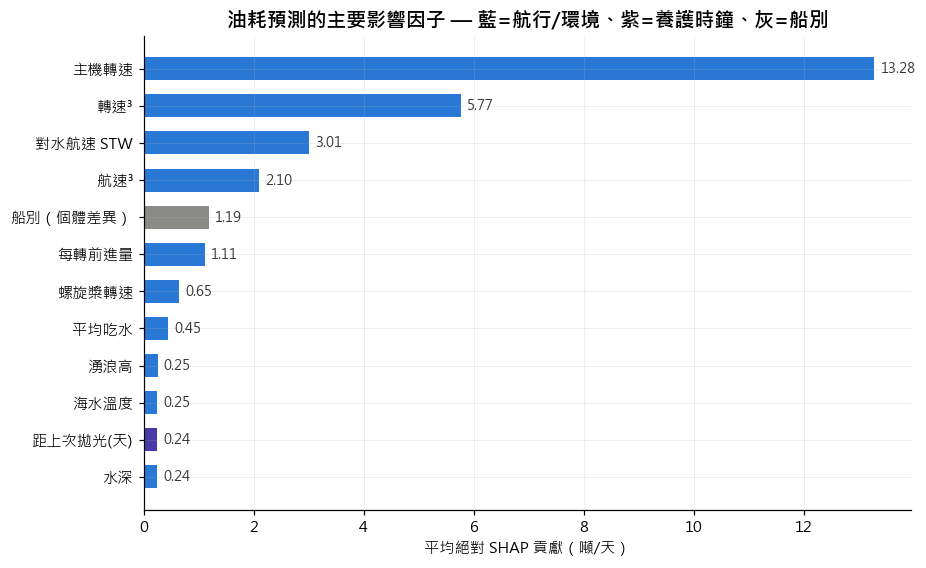

In [2]:
# %% 圖 10：主要影響因子
sample = train.sample(min(4000, len(train)), random_state=0)
dm = xgb.DMatrix(sample[cols])
best = getattr(model, "best_iteration", None)
contrib = model.get_booster().predict(dm, pred_contribs=True,
                                      iteration_range=(0, best + 1) if best is not None else None)
imp = pd.Series(np.abs(contrib[:, :-1]).mean(axis=0), index=cols)
ship_imp = imp[[c for c in cols if c.startswith("ship_S")]].sum()
imp = imp[[c for c in cols if not c.startswith("ship_S")]]
imp.loc["__ship__"] = ship_imp
imp = imp.sort_values().tail(12)
labels = [FEATURE_ZH.get(c, c) if c != "__ship__" else "船別（個體差異）" for c in imp.index]
colors = [CAT["violet"] if c in ("days_since_clean","days_since_polish","days_since_dd")
          else (GRAY if c == "__ship__" else CAT["blue"]) for c in imp.index]
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.barh(labels, imp.values, color=colors, height=0.62)
for y, v in enumerate(imp.values):
    ax.annotate(f"{v:.2f}", (v, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
ax.set_xlabel("平均絕對 SHAP 貢獻（噸/天）")
ax.set_title("油耗預測的主要影響因子 — 藍=航行/環境、紫=養護時鐘、灰=船別")
save("10_shap_importance"); plt.show()

## 2. 養護時鐘的邊際貢獻 — 與它的極限

「距上次清洗天數」的 SHAP 貢獻：**前 ~200 天明確上升**（模型學到剛洗完的船省油）；
但 700 天後反而回落——不是船變乾淨，而是**髒污訊號轉移到轉速/滑差**：
髒的船要用更高 RPM 才跑得動，RPM 特徵把時鐘的功勞吸走了（共線性）。

> 方法論結論：**反事實推論不能天真地把時鐘歸零**（尾端會低估），
> 應改用乾淨基準模型的「超額油耗」——見下一節。這正是我們雙模型架構的價值。

saved: 11_clean_clock_effect


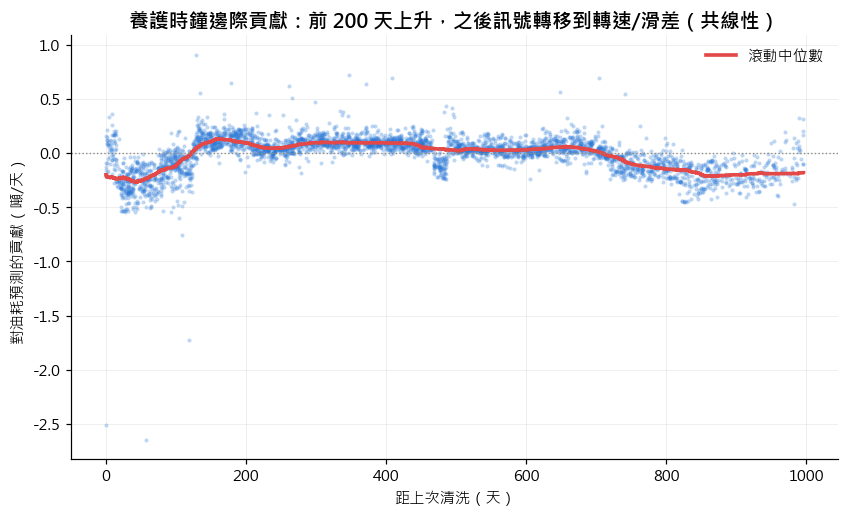

In [3]:
# %% 圖 11：養護時鐘的 SHAP 貢獻曲線
idx = cols.index("days_since_clean")
x = sample["days_since_clean"].to_numpy()
y = contrib[:, idx]
ok = np.isfinite(x) & (x < 1000)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x[ok], y[ok], s=7, alpha=0.3, color=CAT["blue"], linewidths=0)
b = pd.DataFrame({"x": x[ok], "y": y[ok]}).sort_values("x")
b["roll"] = b.y.rolling(300, min_periods=60, center=True).median()
ax.plot(b.x, b.roll, color=CAT["red"], lw=2.4, label="滾動中位數")
ax.axhline(0, color=GRAY, lw=0.9, ls=":")
ax.set_xlabel("距上次清洗（天）"); ax.set_ylabel("對油耗預測的貢獻（噸/天）")
ax.set_title("養護時鐘邊際貢獻：前 200 天上升，之後訊號轉移到轉速/滑差（共線性）")
ax.legend(frameon=False)
save("11_clean_clock_effect"); plt.show()

## 3. 殘差分析 — 誤差有沒有系統性盲區

用遮蔽窗口模擬收集全部逐列誤差，檢查誤差對「航速／距清洗天數」是否存在趨勢
（有趨勢＝模型漏學了什麼；無趨勢＝誤差近隨機）。

saved: 12_residuals


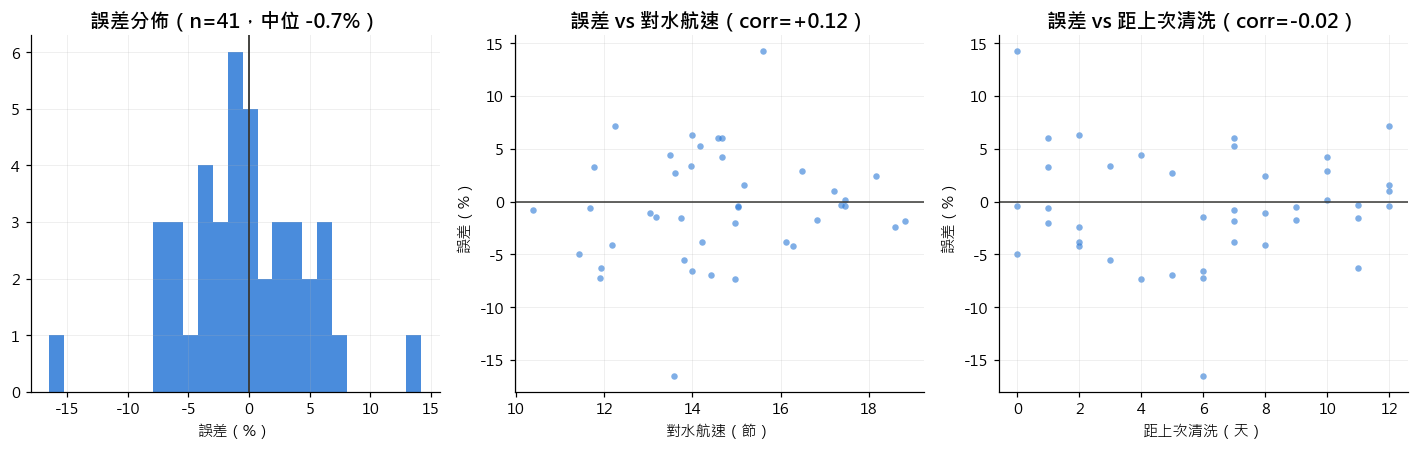

遮蔽窗口逐列誤差：MAPE 3.99% | 偏差 -0.53%


In [4]:
# %% 圖 12：殘差分析（三聯圖）
rows = []
val = masked_window_validation(df, collect_rows=rows)
hv = pd.concat(rows, ignore_index=True)
hv["err_pct"] = (hv["pred"] - hv["daily_foc"]) / hv["daily_foc"] * 100
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
axes[0].hist(hv.err_pct, bins=25, color=CAT["blue"], alpha=0.85)
axes[0].axvline(0, color=INK, lw=1.2)
axes[0].set_xlabel("誤差（%）"); axes[0].set_title(f"誤差分佈（n={len(hv)}，中位 {hv.err_pct.median():+.1f}%）")
for ax_, feat, zh in [(axes[1], "stw", "對水航速（節）"), (axes[2], "days_since_clean", "距上次清洗（天）")]:
    ax_.scatter(hv[feat], hv.err_pct, s=18, alpha=0.6, color=CAT["blue"], linewidths=0)
    ax_.axhline(0, color=INK, lw=1)
    ax_.set_xlabel(zh); ax_.set_ylabel("誤差（%）")
    r = np.corrcoef(hv[feat].fillna(0), hv.err_pct)[0, 1]
    ax_.set_title(f"誤差 vs {zh.split('（')[0]}（corr={r:+.2f}）")
plt.tight_layout()
save("12_residuals"); plt.show()
print(f"遮蔽窗口逐列誤差：MAPE {hv.err_pct.abs().mean():.2f}% | 偏差 {hv.err_pct.mean():+.2f}%")

## 4. 反事實推論：現在清洗/拋光，每天省多少？（命題明文要求）

**方法**：清洗的反事實＝「回到乾淨基準」。乾淨基準模型給出每艘船當前的
超額油耗（實測 − 乾淨基準預測），這就是執行養護可拿回的節省——
與儀表板、ROI 頁、AI 顧問**同一個數字、同一個模型**，全系統自洽。

**船殼 vs 螺旋槳的分割**：用養護事件的實測效果比——純清洗（UWC）中位改善 vs
純拋光（PP）中位改善，從我們自己的事件分析估計兩者的貢獻占比（資料驅動、透明）。

> 上一節說明了為什麼不用監督模型的時鐘歸零法（共線性使尾端低估）。

事件效果中位：清洗 −2.0pp、拋光 −1.1pp → 螺旋槳占比 ≈ 35%


saved: 13_counterfactual_savings


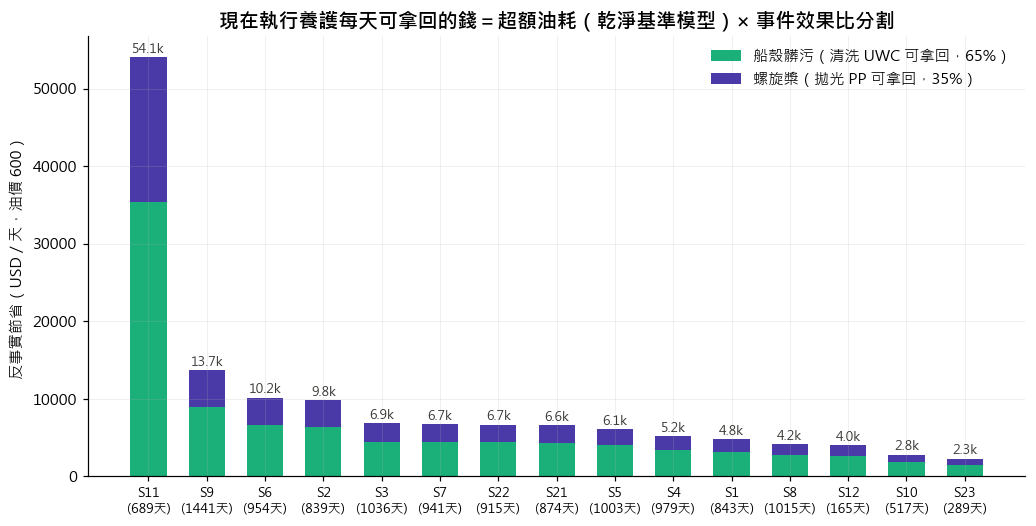

清洗效益前三名: {'S11': 'US$35,336/天', 'S9': 'US$8,942/天', 'S6': 'US$6,631/天'}


In [5]:
# %% 圖 13：反事實清潔效益（乾淨基準模型 + 事件效果比分割）
FUEL_PRICE = 600.0
fleet = pd.read_csv("../data/artifacts/fleet.csv")
scored = pd.read_csv("../data/artifacts/scored.csv", parse_dates=["report_date"])
mt = pd.read_csv("../data/yangming-aws-summit-hackathon/maintenance.csv", parse_dates=["event_date"])

# 事件效果比（同 EDA 圖 5 的計算）→ 船殼 vs 螺旋槳占比
def pre_post_drop(ship, date, win=60, min_n=5):
    g = scored[scored.ship_id == ship]
    pre = g[(g.report_date <  date) & (g.report_date >= date - pd.Timedelta(days=win))].speed_loss_smooth.dropna()
    post= g[(g.report_date >  date) & (g.report_date <= date + pd.Timedelta(days=win))].speed_loss_smooth.dropna()
    return (pre.median() - post.median()) if len(pre) >= min_n and len(post) >= min_n else np.nan
uwc = np.nanmedian([pre_post_drop(e.ship_id, e.event_date) for _, e in mt[mt.event_type.isin(["UWC","UWC+PP"])].iterrows()])
pp  = np.nanmedian([pre_post_drop(e.ship_id, e.event_date) for _, e in mt[mt.event_type == "PP"].iterrows()])
uwc, pp = max(uwc, 0.1), max(pp, 0.0)
prop_share = pp / (pp + uwc)
print(f"事件效果中位：清洗 −{uwc:.1f}pp、拋光 −{pp:.1f}pp → 螺旋槳占比 ≈ {prop_share:.0%}")

f = fleet.sort_values("excess_cost_per_day", ascending=False)
fig, ax = plt.subplots(figsize=(11, 5.2))
xpos = np.arange(len(f))
hull = f.excess_cost_per_day * (1 - prop_share)
prop = f.excess_cost_per_day * prop_share
ax.bar(xpos, hull, width=0.62, color=CAT["aqua"], label=f"船殼髒污（清洗 UWC 可拿回，{1-prop_share:.0%}）")
ax.bar(xpos, prop, width=0.62, bottom=hull, color=CAT["violet"], label=f"螺旋槳（拋光 PP 可拿回，{prop_share:.0%}）")
for x, r in zip(xpos, f.itertuples()):
    ax.annotate(f"{r.excess_cost_per_day/1000:.1f}k", (x, r.excess_cost_per_day),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8.5, color=INK)
ax.set_xticks(xpos)
ax.set_xticklabels([f"{r.ship_id}\n({int(r.days_since_clean)}天)" for r in f.itertuples()], fontsize=8.5)
ax.set_ylabel("反事實節省（USD／天，油價 600）")
ax.set_title("現在執行養護每天可拿回的錢＝超額油耗（乾淨基準模型）× 事件效果比分割")
ax.legend(frameon=False)
save("13_counterfactual_savings"); plt.show()
top = f.head(3)
print("清洗效益前三名:", {r.ship_id: f"US${r.excess_cost_per_day*(1-prop_share):,.0f}/天" for r in top.itertuples()})

## 結論（給簡報）

1. **主要影響因子**：轉速（+轉速³）壓倒性主導——物理上正確（油耗跟功率走），
   且是遮蔽日可見特徵，這就是預測 MAPE 能到 ~5% 的原因。
2. **髒污訊號的去向**：養護時鐘前 200 天有明確邊際貢獻，之後被轉速/滑差吸收
   （髒的船要用更高 RPM）——我們**看得見自己模型的共線性**，並據此選擇反事實方法。
3. **殘差近隨機**：誤差對航速、距清洗天數無明顯趨勢，偏差接近零。
4. **反事實用對工具**：清洗效益＝乾淨基準模型的超額油耗（與儀表板/ROI/顧問同源），
   船殼 vs 螺旋槳用事件實測效果比分割——回應命題的 UWC/PP 反事實要求，
   且三個介面說同一個數字。

**誠實限制**：船殼/螺旋槳占比來自事件中位效果（樣本數有限）；
監督模型的時鐘歸零反事實因共線性在尾端低估，故不採用（見第 2 節）。
